<a href="https://colab.research.google.com/github/dwitajuliandira07/Hasil-UTS-Data-Mining_2304020160_Dwita-Juliandira/blob/main/UTS_Data_Mining_2304020160_Dwita_Juliandira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UTS DATA MINING


DWITA JULIANDIRA
2304020160

# Import Library

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Model Machine Learning
from sklearn.ensemble import RandomForestClassifier

# Evaluasi Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Menyimpan model
import joblib

Pada tahap ini dilakukan import library yang dibutuhkan untuk proses pengolahan data, visualisasi, preprocessing, pembuatan model machine learning, evaluasi model, dan penyimpanan model.

# Load Dataset

In [3]:
# Membaca dataset training
train_df = pd.read_csv('data_training.csv')

# Membaca dataset testing
test_df = pd.read_csv('data_testing.csv')

Dataset training dan testing dibaca menggunakan pandas. Dataset training berisi fitur dan label quality, sedangkan dataset testing hanya berisi fitur tanpa label.

In [53]:
# Menampilkan data training
train_df.head()

# Menampilkan data testing
test_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222.0
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514.0
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417.0
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754.0
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516.0


Fungsi head() digunakan untuk melihat 5 data pertama dari dataset sehingga dapat memahami struktur data dan nama variabel.

# Struktur Dataset

In [6]:
# Informasi dataset training
train_df.info()

# Informasi dataset testing
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data c

Digunakan untuk melihat jumlah data, tipe data, dan keberadaan missing values pada dataset.

In [7]:
print("Ukuran data training:", train_df.shape)
print("Ukuran data testing:", test_df.shape)

Ukuran data training: (857, 13)
Ukuran data testing: (286, 12)


In [8]:
train_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Statistik deskriptif digunakan untuk mengetahui rata-rata, nilai minimum, maksimum, dan persebaran data pada setiap fitur.

# Pengecekan Missing Values

In [9]:
# Missing values pada data training
train_df.isnull().sum()

# Missing values pada data testing
test_df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Digunakan untuk mengecek apakah terdapat data kosong pada dataset. Selanjutnya dataset diperiksa untuk memastikan kualitas data sebelum dilakukan proses machine learning.

In [17]:
# Membuat objek imputasi
imputer = SimpleImputer(strategy='mean')

# Menyimpan kolom
train_columns = train_df.columns

test_columns = test_df.columns

# Imputasi data training
train_df = pd.DataFrame(imputer.fit_transform(train_df), columns=train_columns)

# Imputasi data testing
test_df = pd.DataFrame(imputer.fit_transform(test_df), columns=test_columns)

Missing values ditangani menggunakan imputasi mean, yaitu mengganti nilai kosong dengan rata-rata dari masing-masing variabel.

In [18]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


# Exploratory Data Analysis (EDA)

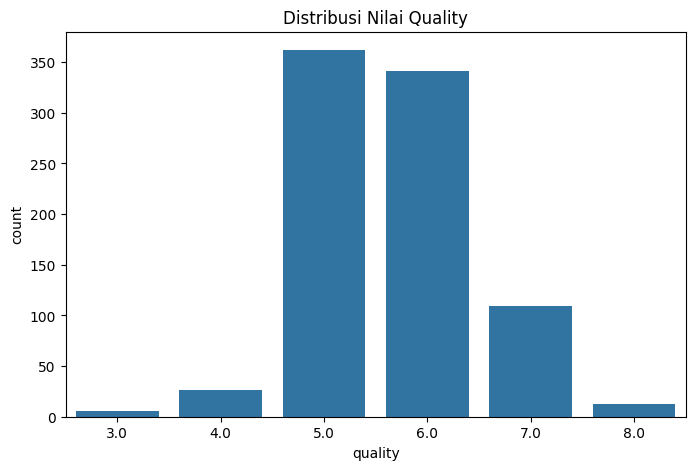

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=train_df)
plt.title('Distribusi Nilai Quality')
plt.show()

Visualisasi ini digunakan untuk melihat distribusi jumlah data pada masing-masing kategori kualitas anggur. Distribusi data quality dapat diketahui sehingga dapat dianalisis apakah data seimbang atau tidak.

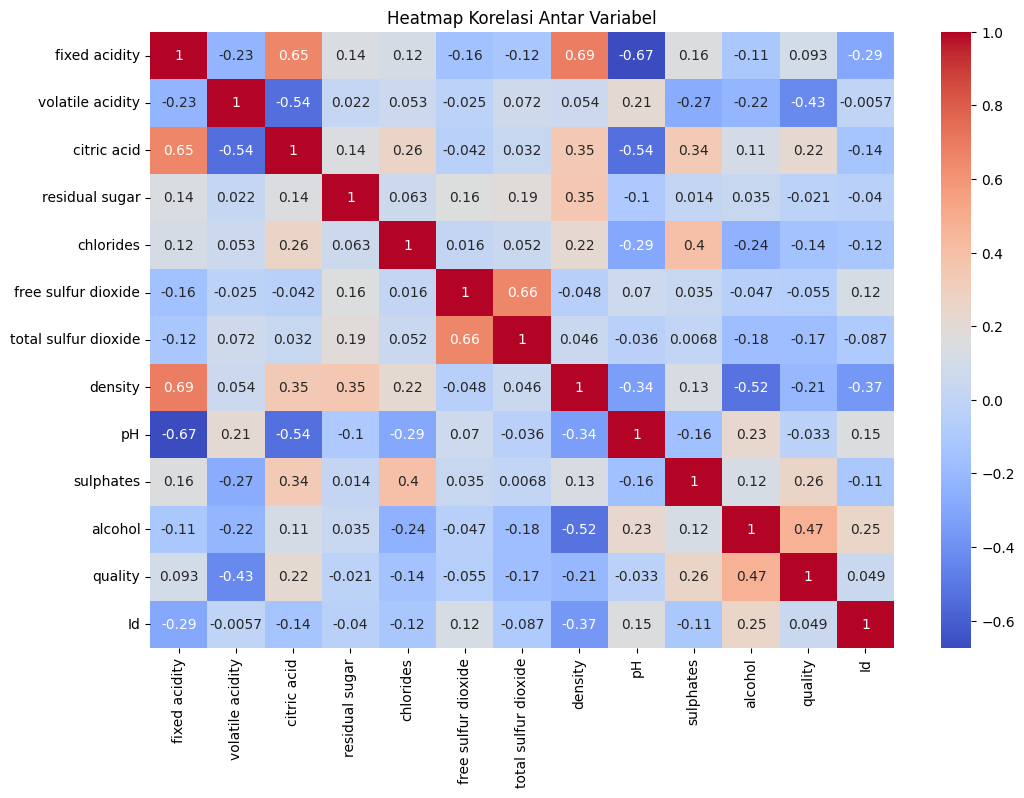

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

Heatmap digunakan untuk melihat hubungan antar variabel dalam dataset.Beberapa fitur memiliki hubungan yang cukup kuat terhadap variabel quality sehingga dapat membantu proses klasifikasi.

# Memisahkan Fitur dan Target

In [21]:
# Memisahkan fitur dan target
X = train_df.drop('quality', axis=1)
y = train_df['quality']

Variabel X berisi fitur-fitur kimiawi anggur, sedangkan y berisi target quality yang akan diprediksi.

# Pembagian Data Training dan Validation

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Dataset dibagi menjadi data training dan validation agar model dapat dievaluasi pada data yang belum pernah dilihat sebelumnya.

In [23]:
print("Jumlah data training:", X_train.shape)
print("Jumlah data validation:", X_val.shape)

Jumlah data training: (685, 12)
Jumlah data validation: (172, 12)


# Feature Scaling

In [24]:
# Membuat objek scaler
scaler = StandardScaler()

# Fit scaler pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform data validation
X_val_scaled = scaler.transform(X_val)

Feature scaling dilakukan untuk menyamakan skala antar fitur karena setiap variabel memiliki rentang nilai yang berbeda.

In [31]:
# Menyiapkan data testing
X_test = test_df.copy()

# Simpan kolom Id jika ada
if 'Id' in X_test.columns:
    test_ids = X_test['Id']
    X_test = X_test.drop('Id', axis=1)
else:
    test_ids = pd.Series(range(len(X_test)))

# Menghapus spasi pada nama kolom
X_train.columns = X_train.columns.str.strip()
X_test.columns = X_test.columns.str.strip()

# Menyamakan kolom testing dengan training
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Scaling data testing
X_test_scaled = scaler.transform(X_test)

# Model Klasifikasi

In [32]:
# Membuat model Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

Model Random Forest digunakan karena mampu menangani data klasifikasi dengan baik dan cukup stabil terhadap overfitting.

In [33]:
# Training model
model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Model dilatih menggunakan data training agar dapat mempelajari pola hubungan antara fitur kimiawi dan kualitas anggur.

# Evaluasi Model

In [34]:
# Prediksi data validation
y_pred = model.predict(X_val_scaled)

Model digunakan untuk memprediksi data validation guna mengevaluasi performa klasifikasi.

In [35]:
accuracy = accuracy_score(y_val, y_pred)
print("Akurasi Model:", accuracy)

Akurasi Model: 0.5988372093023255


Akurasi digunakan untuk mengukur persentase prediksi yang benar dari keseluruhan data validation. Nilai akurasi menunjukkan seberapa baik model dalam memprediksi kualitas anggur.

In [36]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         3.0       0.00      0.00      0.00         1
         4.0       0.00      0.00      0.00         5
         5.0       0.65      0.71      0.68        73
         6.0       0.55      0.62      0.58        68
         7.0       0.53      0.36      0.43        22
         8.0       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.46      0.34      0.37       172
weighted avg       0.58      0.60      0.58       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Menampilkan nilai precision, recall, dan f1-score untuk setiap kelas quality. Model dapat dievaluasi lebih detail pada masing-masing kategori kualitas anggur.

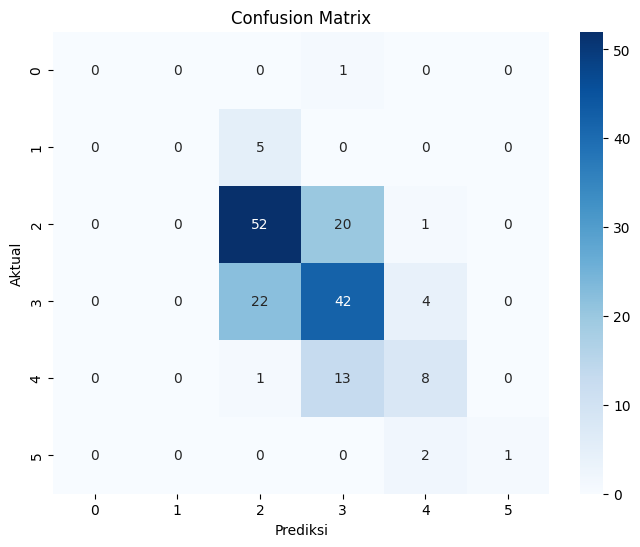

In [37]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas. Hasil confusion matrix menunjukkan performa model dalam membedakan tiap kategori kualitas anggur.

# Menyimpan Model

In [38]:
# Menyimpan model
joblib.dump(model, 'model_wine_quality.pkl')

# Menyimpan scaler
joblib.dump(scaler, 'scaler_wine_quality.pkl')

['scaler_wine_quality.pkl']

Model disimpan agar dapat digunakan kembali tanpa perlu melakukan training ulang.

# Deployment Model pada Data Testing

In [39]:
# Prediksi data testing
predictions = model.predict(X_test_scaled)

Model digunakan untuk memprediksi nilai quality pada dataset testing yang belum memiliki label.

In [40]:
predictions[:10]

array([6., 6., 5., 5., 5., 6., 5., 5., 6., 5.])

# Membuat File Submission CSV

In [41]:
# Membuat dataframe submission
submission = pd.DataFrame({
    'Id': test_ids,
    'quality': predictions
})

Hasil prediksi disimpan ke dalam file CSV sesuai format.

In [48]:
submission.head(287)

,Id,quality
0,222.0,6.0
1,1514.0,6.0
2,417.0,5.0
3,754.0,5.0
4,516.0,5.0
...,...,...
281,1147.0,6.0
282,296.0,5.0
283,170.0,5.0
284,1439.0,6.0


In [49]:
submission.to_csv('hasil_prediksi_wine_quality.csv', index=False)

# Download File Hasil Prediksi

In [50]:
from google.colab import files
files.download('hasil_prediksi_wine_quality.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Berdasarkan proses yang telah dilakukan, model klasifikasi Random Forest berhasil digunakan untuk memprediksi kualitas anggur berdasarkan fitur-fitur kimiawi pada dataset Wine Quality. Tahapan preprocessing seperti penanganan missing values dan feature scaling membantu meningkatkan kualitas data sebelum pelatihan model dilakukan. Evaluasi model menggunakan accuracy, classification report, dan confusion matrix menunjukkan bahwa model mampu melakukan klasifikasi dengan cukup baik. Model yang telah dilatih kemudian berhasil digunakan untuk memprediksi kualitas pada dataset testing dan hasil prediksi disimpan dalam format CSV.